# Modelos LSTM y similitud catch22 — Movimiento de Viajeros

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import copy

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE


device(type='cpu')

## 1. Carga y preparación de datos

In [2]:
def cargar_csv_robusto(path):
    intentos = [
        {"encoding": "utf-8-sig", "sep": ","},
        {"encoding": "utf-8", "sep": ","},
        {"encoding": "latin-1", "sep": ","},
        {"encoding": "cp1252", "sep": ","},
    ]
    for params in intentos:
        try:
            df_test = pd.read_csv(path, **params, nrows=50)
            cols_ok = any("ñ" in c or "í" in c or "ó" in c for c in df_test.columns)
            texto_roto = any("M-CM-" in c or "AM-CM" in c for c in df_test.columns)
            if cols_ok and not texto_roto:
                return pd.read_csv(path, **params)
        except Exception:
            continue

    df_raw = pd.read_csv(path, encoding="latin-1", sep=",")

    def fix_text(x):
        if isinstance(x, str):
            try:
                return x.encode("latin-1").decode("utf-8")
            except (UnicodeDecodeError, UnicodeEncodeError):
                return x
        return x

    df_raw.columns = [fix_text(c) for c in df_raw.columns]
    for col in df_raw.select_dtypes(include="object").columns:
        df_raw[col] = df_raw[col].apply(fix_text)
    return df_raw


df = cargar_csv_robusto("../data/raw/Base_Migracion_2009-2026jun.csv")
df.columns = [c.strip() for c in df.columns]

rename_map = {
    "AM-CM-1o": "Año", "Mes cod": "Mes_cod", "VM-CM--a": "Vía",
    "PaM-CM--s": "País", "RegiM-CM-3n": "Región", "RegiM-CM-3n dos": "Región_dos",
    "AgrupaciM-CM-3n Residencia": "Agrupación_Residencia", "Tipo de Viajero": "Tipo_Viajero",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

df["Año"] = pd.to_numeric(df["Año"], errors="coerce").astype("Int64")
df["Mes_cod"] = pd.to_numeric(df["Mes_cod"], errors="coerce").astype("Int64")
df["Viajero"] = pd.to_numeric(df["Viajero"], errors="coerce")
df["Fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes_cod"], day=1), errors="coerce")
df = df.dropna(subset=["Fecha", "Viajero"])

df.head()


,Año,Mes_cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo_Viajero,Viajero,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,2009-01-01
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0,2009-01-01
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0,2009-01-01


## 2. Series de tiempo a modelar

In [3]:
serie_total = df.groupby("Fecha")["Viajero"].sum().sort_index()

series_tipo = {
    f"Tipo_{tipo}": g.groupby("Fecha")["Viajero"].sum().sort_index()
    for tipo, g in df.groupby("Tipo_Viajero")
}

series_via = {
    f"Via_{via}": g.groupby("Fecha")["Viajero"].sum().sort_index()
    for via, g in df.groupby("Vía")
}

SERIES = {"Total": serie_total, **series_tipo, **series_via}
SERIES = {k: v.asfreq("MS").fillna(0.0) for k, v in SERIES.items() if len(v) >= 40}

{k: len(v) for k, v in SERIES.items()}


{'Total': 210,
 'Tipo_Cruceristas': 168,
 'Tipo_Excursionista': 210,
 'Tipo_Turista': 210,
 'Tipo_Viajero': 210,
 'Via_Aérea': 210,
 'Via_Marítima': 210,
 'Via_Terrestre': 210}

## 3. Utilidades: ventanas, split y escalado

In [4]:
WINDOW_GRID = [6, 12]

def create_sequences(values, window_size):
    X, y = [], []
    for i in range(len(values) - window_size):
        X.append(values[i:i + window_size])
        y.append(values[i + window_size])
    return np.array(X), np.array(y)


def prepare_series(values, window_size, test_ratio=0.2):
    n = len(values)
    split_idx = int(n * (1 - test_ratio))

    scaler = MinMaxScaler()
    scaler.fit(values[:split_idx].reshape(-1, 1))
    scaled = scaler.transform(values.reshape(-1, 1)).flatten()

    X, y = create_sequences(scaled, window_size)
    target_idx = np.arange(window_size, n)
    train_mask = target_idx < split_idx

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[~train_mask], y[~train_mask]
    return X_train[..., None], y_train, X_test[..., None], y_test, scaler


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


## 4. LSTM

In [5]:
class LSTMSimple(nn.Module):
    def __init__(self, units=32, **kwargs):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=units, batch_first=True)
        self.fc = nn.Linear(units, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class LSTMStacked(nn.Module):
    def __init__(self, units=32, dropout=0.2, **kwargs):
        super().__init__()
        units2 = max(units // 2, 4)
        self.lstm1 = nn.LSTM(input_size=1, hidden_size=units, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(input_size=units, hidden_size=units2, batch_first=True)
        self.fc = nn.Linear(units2, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.drop(out)
        out, _ = self.lstm2(out)
        return self.fc(out[:, -1, :])


PARAM_GRID = [
    {"window_size": 6, "units": 16, "dropout": 0.1, "lr": 1e-3},
    {"window_size": 12, "units": 32, "dropout": 0.2, "lr": 1e-3},
    {"window_size": 12, "units": 64, "dropout": 0.3, "lr": 5e-4},
]

ARCHITECTURES = {
    "LSTM_simple": LSTMSimple,
    "LSTM_stacked": LSTMStacked,
}


## 5. Tuneo de hiperparámetros y entrenamiento por serie

In [6]:
def train_torch_model(model, X_tr, y_tr, X_val, y_val, lr, epochs=100, batch_size=16, patience=8):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    X_val_t = torch.tensor(X_val).to(DEVICE)
    y_val_t = torch.tensor(y_val).to(DEVICE)

    best_val = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb).squeeze(-1)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t).squeeze(-1)
            val_loss = loss_fn(val_pred, y_val_t).item()

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val


def tune_series(name, series, epochs=100, batch_size=16, patience=8):
    values = series.values.astype("float32")
    trials = []

    for arch_name, model_cls in ARCHITECTURES.items():
        for params in PARAM_GRID:
            ws = params["window_size"]
            X_train, y_train, X_test, y_test, scaler = prepare_series(values, ws)
            if len(X_train) < 20 or len(X_test) < 4:
                continue

            val_split = int(len(X_train) * 0.85)
            X_tr, y_tr = X_train[:val_split], y_train[:val_split]
            X_val, y_val = X_train[val_split:], y_train[val_split:]

            torch.manual_seed(SEED)
            kwargs = dict(units=params["units"])
            if arch_name == "LSTM_stacked":
                kwargs["dropout"] = params["dropout"]
            model = model_cls(**kwargs)

            model, val_rmse_scaled = train_torch_model(
                model, X_tr, y_tr, X_val, y_val, lr=params["lr"],
                epochs=epochs, batch_size=batch_size, patience=patience,
            )
            val_rmse_scaled = float(np.sqrt(val_rmse_scaled))

            trials.append({
                "serie": name, "arch": arch_name, **params,
                "val_rmse_scaled": val_rmse_scaled,
                "model": model, "scaler": scaler,
                "X_test": X_test, "y_test": y_test,
            })

    if not trials:
        return None, None

    best = min(trials, key=lambda t: t["val_rmse_scaled"])
    trials_df = pd.DataFrame(trials).drop(columns=["model", "scaler", "X_test", "y_test"])
    return best, trials_df


all_trials = []
best_per_series = {}

for name, series in SERIES.items():
    best, trials_df = tune_series(name, series)
    if best is None:
        continue
    best_per_series[name] = best
    all_trials.append(trials_df)

trials_summary = pd.concat(all_trials, ignore_index=True)
trials_summary.sort_values(["serie", "val_rmse_scaled"]).head(20)


,serie,arch,window_size,units,dropout,lr,val_rmse_scaled
10,Tipo_Cruceristas,LSTM_stacked,12,32,0.2,0.0010,0.145965
6,Tipo_Cruceristas,LSTM_simple,6,16,0.1,0.0010,0.227334
7,Tipo_Cruceristas,LSTM_simple,12,32,0.2,0.0010,0.305415
11,Tipo_Cruceristas,LSTM_stacked,12,64,0.3,0.0005,0.307585
8,Tipo_Cruceristas,LSTM_simple,12,64,0.3,0.0005,0.313285
9,Tipo_Cruceristas,LSTM_stacked,6,16,0.1,0.0010,0.318974
13,Tipo_Excursionista,LSTM_simple,12,32,0.2,0.0010,0.112542
14,Tipo_Excursionista,LSTM_simple,12,64,0.3,0.0005,0.117876
16,Tipo_Excursionista,LSTM_stacked,12,32,0.2,0.0010,0.119303
17,Tipo_Excursionista,LSTM_stacked,12,64,0.3,0.0005,0.121509


## 6. Evaluación en test del mejor modelo por serie

In [7]:
def evaluate_best(best):
    model, scaler = best["model"], best["scaler"]
    X_test, y_test = best["X_test"], best["y_test"]

    model.eval()
    with torch.no_grad():
        y_pred_scaled = model(torch.tensor(X_test).to(DEVICE)).squeeze(-1).cpu().numpy()

    y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_orig = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    return {
        "serie": best["serie"],
        "arch": best["arch"],
        "window_size": best["window_size"],
        "units": best["units"],
        "lr": best["lr"],
        "RMSE": rmse(y_test_orig, y_pred_orig),
        "MAE": mean_absolute_error(y_test_orig, y_pred_orig),
        "MAPE": mean_absolute_percentage_error(y_test_orig, y_pred_orig),
        "y_test": y_test_orig,
        "y_pred": y_pred_orig,
    }


eval_results = {name: evaluate_best(best) for name, best in best_per_series.items()}

metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("y_test", "y_pred")}
    for r in eval_results.values()
]).sort_values("RMSE")

metrics_df


,serie,arch,window_size,units,lr,RMSE,MAE,MAPE
6,Via_Marítima,LSTM_simple,12,32,0.0010,512.784189,498.285248,9.697708e-01
1,Tipo_Cruceristas,LSTM_stacked,12,32,0.0010,6534.541147,5536.878906,1.929982e+19
4,Tipo_Viajero,LSTM_simple,6,16,0.0010,12045.297174,6725.903809,2.802330e-01
2,Tipo_Excursionista,LSTM_simple,12,32,0.0010,13808.439738,10650.668945,1.696997e-01
5,Via_Aérea,LSTM_simple,6,16,0.0010,17731.845251,14657.974609,1.675423e-01
3,Tipo_Turista,LSTM_simple,12,64,0.0005,38867.003589,31052.539062,1.632608e-01
7,Via_Terrestre,LSTM_simple,12,64,0.0005,44248.109203,34444.429688,1.797285e-01
0,Total,LSTM_simple,12,64,0.0005,57448.982028,42604.167969,1.506934e-01


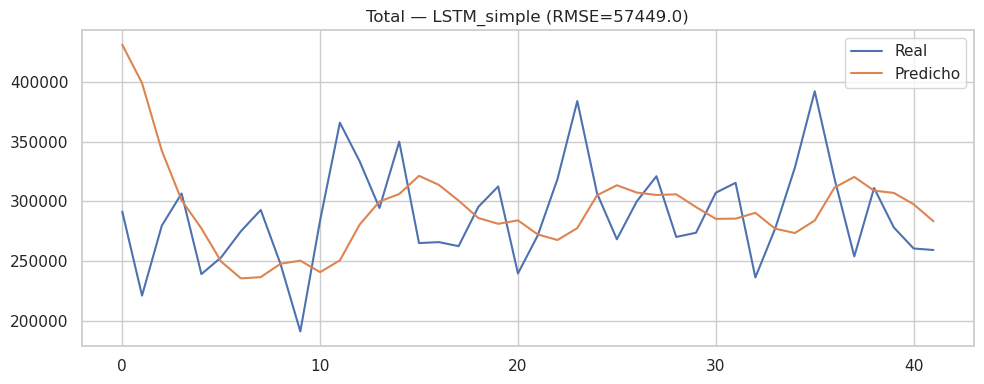

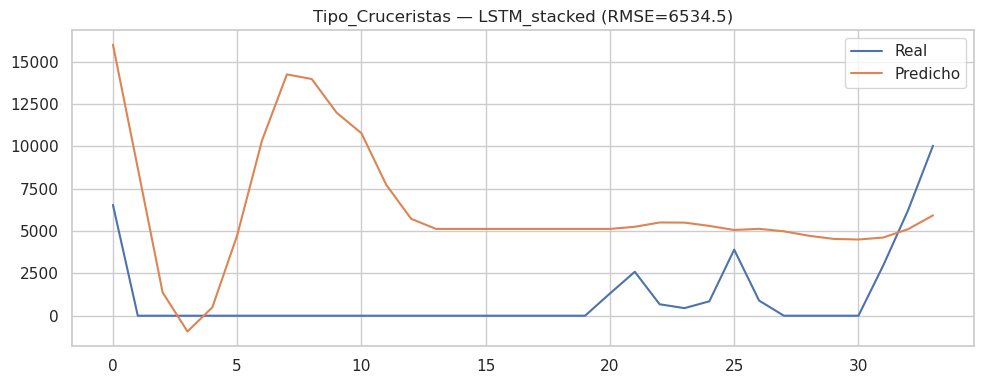

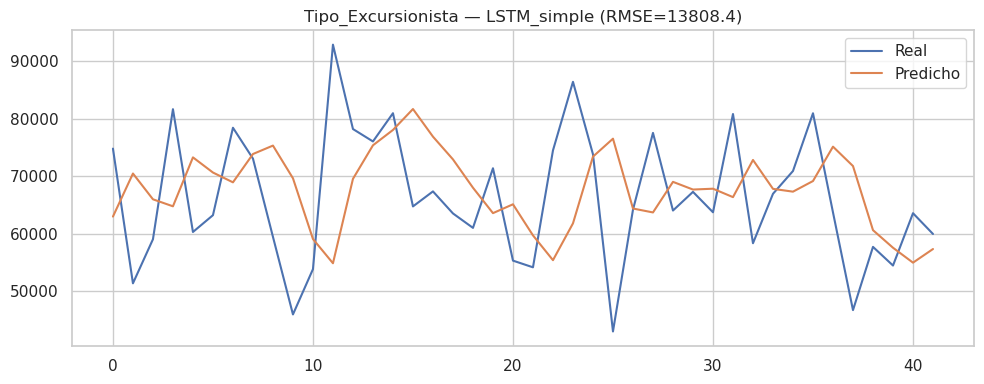

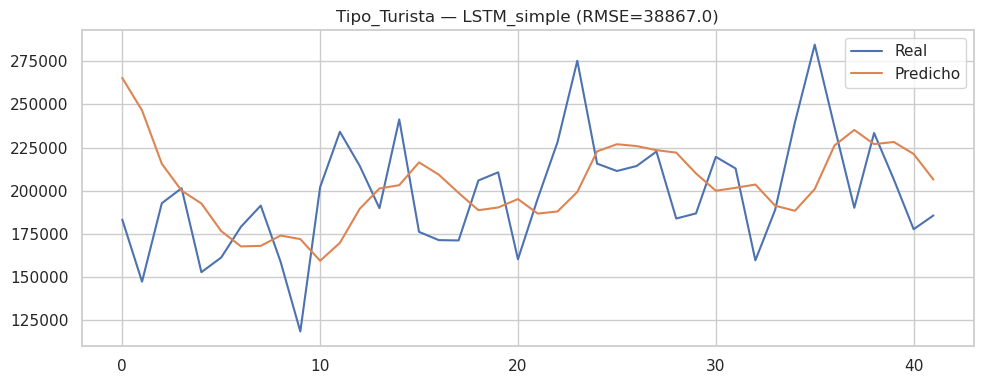

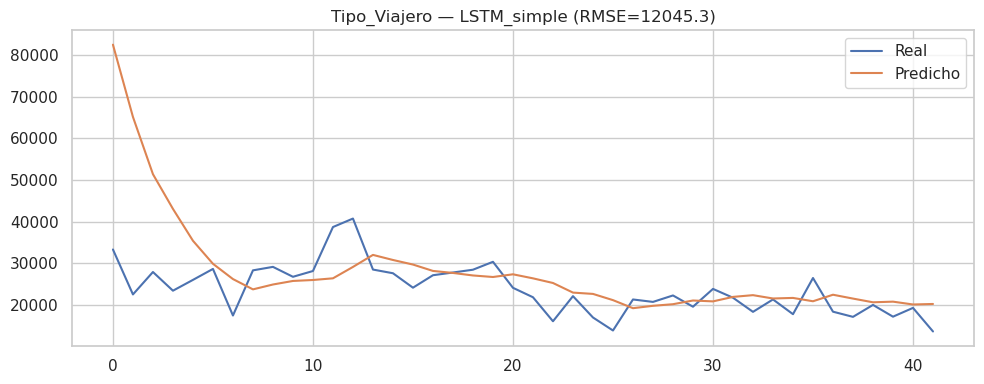

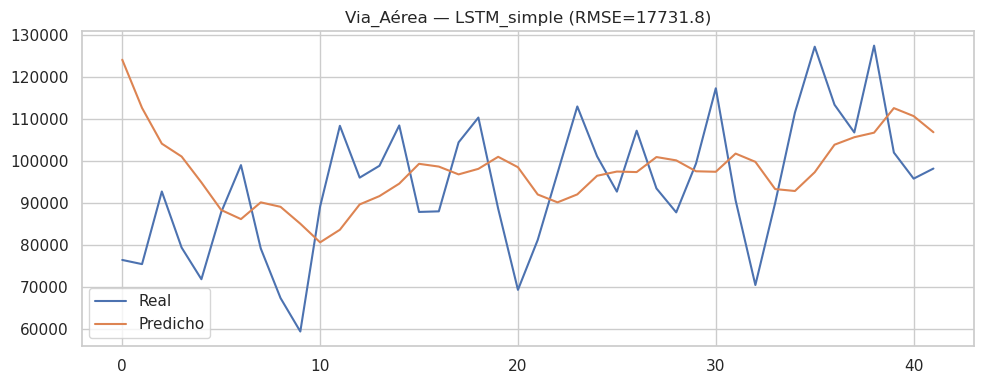

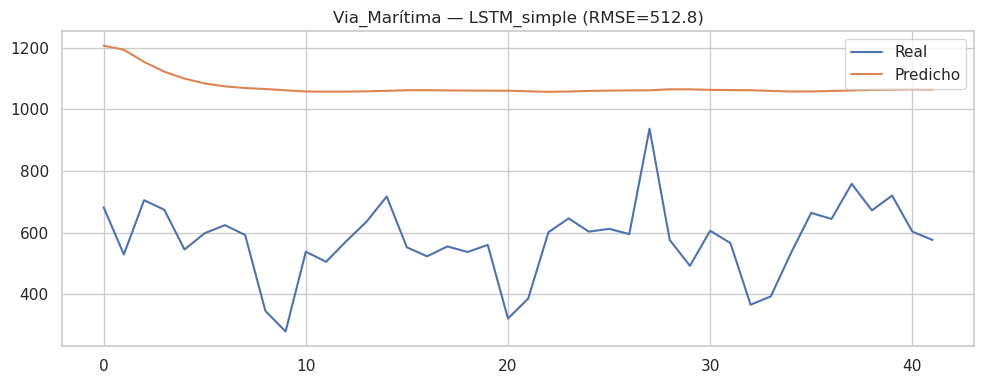

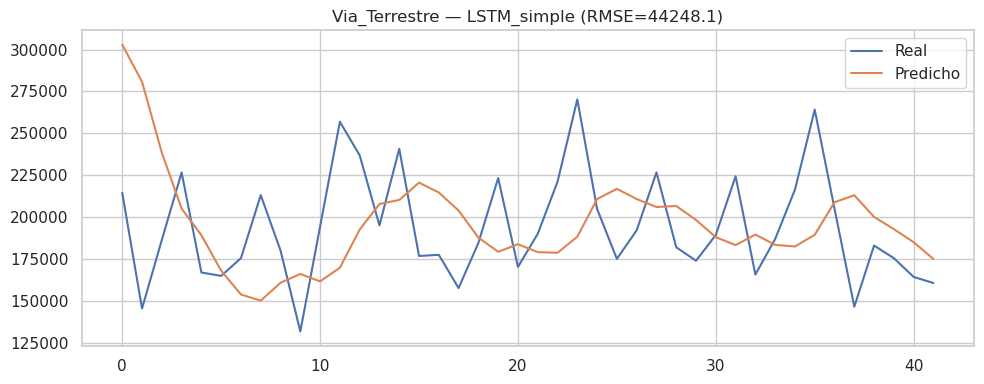

In [8]:
for name, r in eval_results.items():
    plt.figure(figsize=(10, 4))
    plt.plot(r["y_test"], label="Real")
    plt.plot(r["y_pred"], label="Predicho")
    plt.title(f"{name} — {r['arch']} (RMSE={r['RMSE']:.1f})")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 7. Similitud entre series con catch22

In [9]:
!pip install pycatch22 -q


fish: Unknown command: pip
fish: 
pip install pycatch22 -q
^~^


In [10]:
import pycatch22

def catch22_features(series_dict):
    feat_rows = {}
    feat_names = None
    for name, s in series_dict.items():
        vals = s.values.astype(float).tolist()
        res = pycatch22.catch22_all(vals)
        if feat_names is None:
            feat_names = res["names"]
        feat_rows[name] = res["values"]
    return pd.DataFrame(feat_rows, index=feat_names).T


feat_df = catch22_features(SERIES)
feat_df.head()


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total,0.188540,-0.580353,8.578892,10.0,0.453530,-0.126601,0.913876,30.0,0.013774,11.0,...,0.055556,0.219048,0.323810,0.829129,6.0,1.846797,0.761905,0.857143,0.147262,0.627355
Tipo_Cruceristas,-0.529704,-0.745388,1.928428,6.0,0.111917,-0.073415,0.820359,9.0,0.006122,11.0,...,0.200000,0.297619,0.363095,0.711107,5.0,2.022264,0.146341,0.731707,0.515418,0.939798
Tipo_Excursionista,-0.351261,-0.579081,10.624822,15.0,0.510622,-0.042198,0.904306,30.0,0.005510,52.0,...,0.052632,0.266667,0.319048,0.853298,4.0,1.793196,0.761905,0.857143,0.098175,0.554374
Tipo_Turista,-0.036878,0.224708,8.721277,2.0,0.266628,-0.070405,0.971292,30.0,0.013774,3.0,...,0.055556,0.152381,0.323810,0.794164,6.0,1.868443,0.857143,0.857143,0.147262,0.670087
Tipo_Viajero,-0.344914,-0.606070,7.272866,11.0,0.305492,-0.450194,0.751196,18.0,0.041667,35.0,...,0.023810,0.557143,-0.452381,0.804758,5.0,1.825859,0.857143,0.571429,0.171806,0.667356


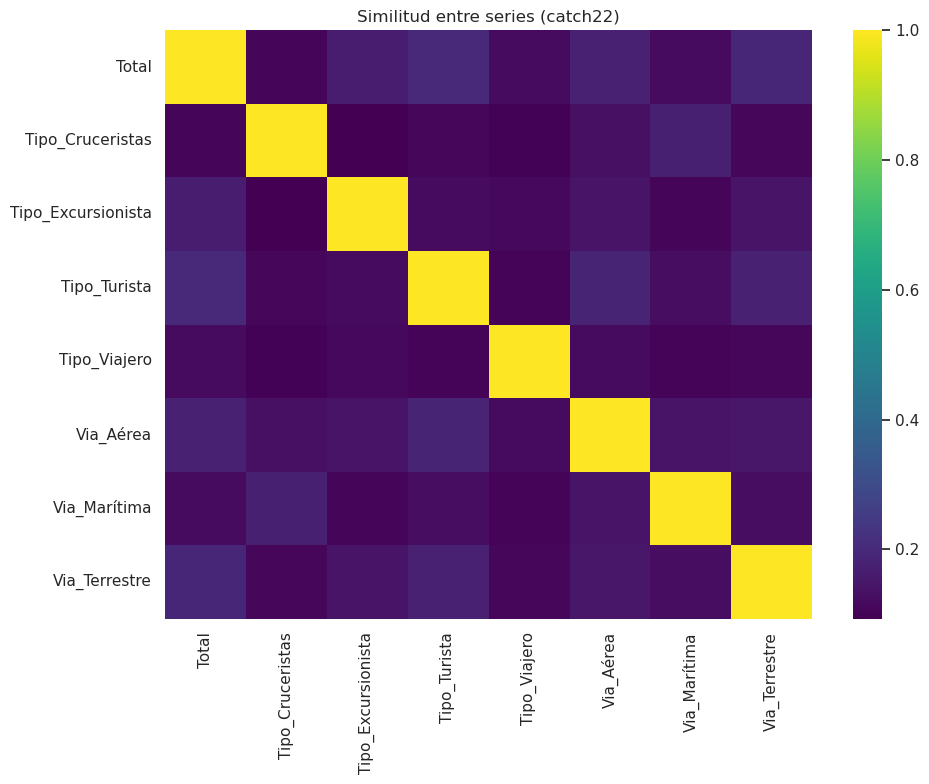

In [11]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform

feat_scaled = StandardScaler().fit_transform(feat_df.values)
dist_matrix = squareform(pdist(feat_scaled, metric="euclidean"))
dist_df = pd.DataFrame(dist_matrix, index=feat_df.index, columns=feat_df.index)

sim_df = 1 / (1 + dist_df)

plt.figure(figsize=(10, 8))
sns.heatmap(sim_df, cmap="viridis", annot=False)
plt.title("Similitud entre series (catch22)")
plt.tight_layout()
plt.show()


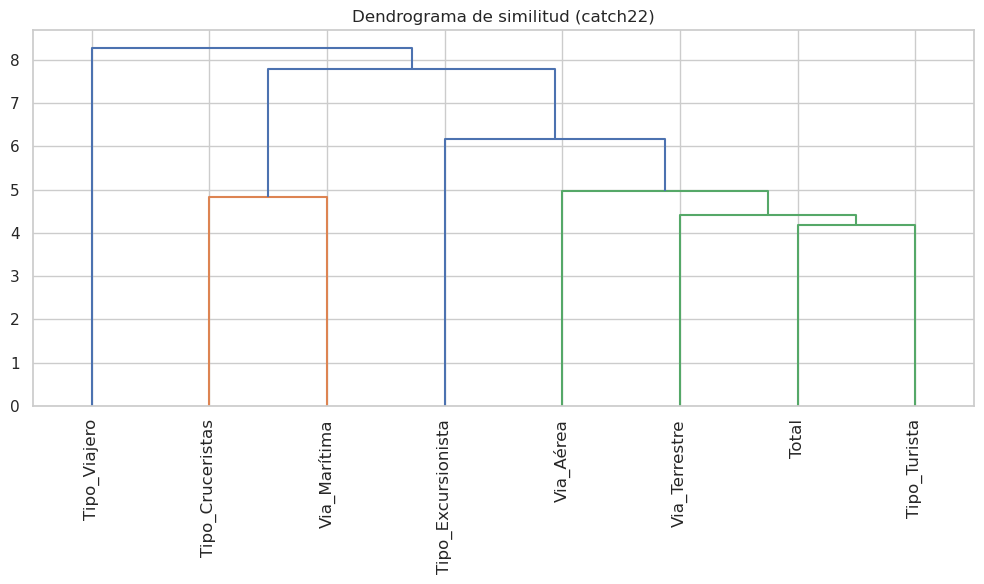

In [12]:
link = linkage(pdist(feat_scaled, metric="euclidean"), method="average")

plt.figure(figsize=(10, 6))
dendrogram(link, labels=feat_df.index.tolist(), leaf_rotation=90)
plt.title("Dendrograma de similitud (catch22)")
plt.tight_layout()
plt.show()
